# Apply for Colab

In [2]:
!ls
!pwd

drive  sae-lof-ids-pi5	sample_data
/content


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!git clone https://github.com/nguyenxuanha20210301/sae-lof-ids-pi5.git
%cd sae-lof-ids-pi5

Cloning into 'sae-lof-ids-pi5'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 40 (delta 7), reused 35 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 273.24 KiB | 6.21 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/sae-lof-ids-pi5/sae-lof-ids-pi5


In [1]:
import os

# Đường dẫn đến nơi dữ liệu thực sự nằm trong Drive của bạn
drive_path = '/content/drive/MyDrive/datasets/CICIoT2023/processed/processed/'

# Đường dẫn mà code trong Notebook đang mong đợi (dựa theo ảnh bạn chụp)
expected_path = '/content/sae-lof-ids-pi5/data/processed'

# Tạo thư mục cha nếu chưa có (để tránh lỗi)
os.makedirs('/content/sae-lof-ids-pi5/data/', exist_ok=True)

# Tạo liên kết từ Drive sang thư mục của Repo
!ln -s "{drive_path}" "{expected_path}"

print("Đã kết nối dữ liệu từ Drive vào thư mục dự án!")

/content


In [ ]:
# check xem data da duoc lien ket chua?
!ls /content/sae-lof-ids-pi5/data/processed

# 03 — SAE v0 sub-sample training + mini grid search ρ/β

**Tuần 3 (06/05 – 12/05 2026)** — Đồ án tốt nghiệp SAE+LOF trên CIC-IoT2023 + Pi 5

## Mục tiêu

1. Verify pipeline PyTorch (Model + Loss + Dataset + Train loop) chạy trên parquet thật của EDA Tuần 2
2. Train SAE base config (ρ=0.05, β=3.0) trên sub-sample ~50k benign flow
3. Mini grid search **ρ ∈ {0.01, 0.05, 0.10} × β ∈ {1, 3, 10}** (9 combo) để chọn 1–2 điểm đẹp cho Tuần 4 grid đầy đủ + 5 seed
4. Sanity check: recon error trên **benign val** phải < recon error trên **attack val** (tín hiệu SAE đang học đúng manifold benign)

## Input (từ EDA Tuần 2)

```
/home/kali/sae-lof-ids-pi5/data/processed/
    train_benign.parquet   # 878,556 benign flow
    val.parquet            # 4,668,658 flow (có cả benign + attack)
    scaler_benign.pkl      # đã fit trên benign-train
    label_encoder_8.pkl
    label_encoder_34.pkl
```

## Output của notebook này

- `checkpoints/sae_v0_base_best.pt` — model tốt nhất config base
- `logs/sae_v0_base_history.json` — learning curves
- `logs/grid_<timestamp>/summary.csv` + 9 file JSON history — kết quả grid
- `figs/03_learning_curve.png`, `03_recon_hist.png`, `03_grid_heatmap.png`
- **Quyết định:** chọn (ρ\*, β\*) tốt nhất → ghi vào `configs/sae_v0_tuned.yaml` cho Tuần 4

## 0. Setup & imports

In [ ]:
import sys, os, json, time
from pathlib import Path

# Root project — đổi nếu cần

# For PC
# PROJ_ROOT = Path('/home/kali/sae-lof-ids-pi5')

# For Colab
PROJ_ROOT = Path('/content/sae-lof-ids-pi5')

sys.path.insert(0, str(PROJ_ROOT / 'src'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sae_model   import SparseAutoencoder
from sae_losses  import sae_loss
from sae_dataset import BenignFlowDataset, make_dataloaders
from sae_train   import TrainConfig, train, evaluate, set_seed

DATA_DIR = PROJ_ROOT / 'data' / 'processed'
FIG_DIR  = PROJ_ROOT / 'figs';        FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = PROJ_ROOT / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR  = PROJ_ROOT / 'logs';        LOG_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.11.0+cu130  |  device: cpu


## 1. Sanity-check dữ liệu parquet

In [ ]:
# Peek metadata mà không load full 1.5 GB train.parquet
for name in ['train_benign.parquet', 'val.parquet']:
    p = DATA_DIR / name
    sz = p.stat().st_size / 1e6
    # pyarrow metadata không load data
    import pyarrow.parquet as pq
    meta = pq.read_metadata(p)
    print(f'{name:30s} {sz:8.1f} MB  rows={meta.num_rows:>12,d}  cols={meta.num_columns}')

train_benign.parquet               53.2 MB  rows=     878,556  cols=49
val.parquet                       182.6 MB  rows=   4,668,658  cols=49


In [ ]:
# Đọc vài dòng đầu để confirm schema
head = pd.read_parquet(DATA_DIR / 'train_benign.parquet').head(3)
print('Columns:', list(head.columns))
print(f'n cols = {head.shape[1]}')
head

Columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'y_bin', 'y8', 'y34']
n cols = 49


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,y_bin,y8,y34
0,-0.495997,-0.551590,-0.173219,-0.694403,-0.095920,-0.095920,0.0,-0.002386,-0.006221,-0.006996,...,-1.000287,-0.999165,0.855420,0.177683,-0.142571,0.160843,-0.999380,0,0,1
1,-0.049844,0.824556,-0.173219,-1.026020,-0.099534,-0.099534,0.0,-0.002386,-0.006221,-0.006996,...,0.999709,1.000361,0.613119,0.888428,0.209631,0.588211,1.000685,0,0,1
2,-0.282399,0.629550,-0.660411,-0.994809,-0.098478,-0.098478,0.0,-0.002386,-0.006221,-0.006996,...,0.999696,1.000361,1.117857,0.478906,-0.028938,0.588211,1.000685,0,0,1


In [ ]:
# Diagnostic — xem file .pkl thật sự là format gì
from pathlib import Path

DATA_DIR = Path('/home/kali/sae-lof-ids-pi5/data/processed')
for fname in ['label_encoder_8.pkl', 'label_encoder_34.pkl', 'scaler_benign.pkl']:
    p = DATA_DIR / fname
    if not p.exists():
        print(f'{fname}: KHÔNG TỒN TẠI')
        continue
    # Đọc 8 byte đầu để xem magic
    with open(p, 'rb') as f:
        head = f.read(16)
    print(f'{fname}: size={p.stat().st_size} bytes, magic={head[:4].hex()} first={head!r}')

label_encoder_8.pkl: size=541 bytes, magic=80049512 first=b'\x80\x04\x95\x12\x01\x00\x00\x00\x00\x00\x00\x8c\x1cskl'
label_encoder_34.pkl: size=1103 bytes, magic=80049512 first=b'\x80\x04\x95\x12\x01\x00\x00\x00\x00\x00\x00\x8c\x1cskl'
scaler_benign.pkl: size=1687 bytes, magic=8004958b first=b'\x80\x04\x95\x8b\x01\x00\x00\x00\x00\x00\x00\x8c\x1bskl'


In [ ]:
# Kiểm label_encoder_8.pkl để biết benign encoded là gì
# EDA dùng joblib (phổ biến với sklearn objects), thử joblib trước, fallback pickle
import joblib
import pickle

le8_path = DATA_DIR / 'label_encoder_8.pkl'
le8 = None
if le8_path.exists():
    try:
        le8 = joblib.load(le8_path)
    except Exception:
        with open(le8_path, 'rb') as f:
            le8 = pickle.load(f)

if le8 is not None and hasattr(le8, 'classes_'):
    print('8-class label encoder classes:')
    for i, c in enumerate(le8.classes_):
        print(f'  {i}: {c}')
    BENIGN_LABEL = None
    for i, c in enumerate(le8.classes_):
        if str(c).lower() in ('benign', 'benigntraffic', 'normal', 'benign traffic'):
            BENIGN_LABEL = i
            print(f'\n==> BENIGN_LABEL = {BENIGN_LABEL} (tên: "{c}")')
            break
    if BENIGN_LABEL is None:
        BENIGN_LABEL = 0
        print(f'\n==> Fallback BENIGN_LABEL = 0')
else:
    BENIGN_LABEL = 0
    print('label_encoder không load được, giả định BENIGN_LABEL = 0')

8-class label encoder classes:
  0: Benign
  1: BruteForce
  2: DDoS
  3: DoS
  4: Mirai
  5: Recon
  6: Spoofing
  7: Web

==> BENIGN_LABEL = 0 (tên: "Benign")


## 2. Train SAE config base (ρ=0.05, β=3.0) trên sub-sample

In [ ]:
# Config base theo đề cương, sub-sample 50k để iteration nhanh
cfg_base = TrainConfig(
    train_path=str(DATA_DIR / 'train_benign.parquet'),
    val_path  =str(DATA_DIR / 'val.parquet'),
    benign_label=BENIGN_LABEL,
    max_train_samples=50_000,
    max_val_samples  =20_000,
    input_dim=46, hidden_dims=(32, 16), latent_dim=8,
    rho=0.05, beta=3.0,
    lr=1e-3, batch_size=256,
    max_epochs=50, patience=10,
    num_workers=2, device='auto', seed=0,
    run_name='sae_v0_base',
    ckpt_dir=str(CKPT_DIR), log_dir=str(LOG_DIR),
    verbose_every=2,
)
print('Config base:', cfg_base)

Config base: TrainConfig(train_path='/home/kali/sae-lof-ids-pi5/data/processed/train_benign.parquet', val_path='/home/kali/sae-lof-ids-pi5/data/processed/val.parquet', benign_label=0, max_train_samples=50000, max_val_samples=20000, input_dim=46, hidden_dims=(32, 16), latent_dim=8, rho=0.05, beta=3.0, lr=0.001, batch_size=256, max_epochs=50, patience=10, num_workers=2, device='auto', seed=0, run_name='sae_v0_base', ckpt_dir='/home/kali/sae-lof-ids-pi5/checkpoints', log_dir='/home/kali/sae-lof-ids-pi5/logs', verbose_every=2)


In [ ]:
# Verify dataset loader đọc đúng schema EDA
from sae_dataset import BenignFlowDataset

ds_train = BenignFlowDataset(
    DATA_DIR / 'train_benign.parquet',
    benign_label=None,  # train_benign thuần benign, không cần lọc
    max_samples=1000,
    seed=0,
)
print(f'train_benign: {ds_train.summary()}')
print(f'n_features = {ds_train.n_features}')
print(f'First 5 feature names: {ds_train.feature_cols[:5]}')
print(f'Last 5 feature names: {ds_train.feature_cols[-5:]}')

ds_val = BenignFlowDataset(
    DATA_DIR / 'val.parquet',
    benign_label=0,  # lọc benign (y8==0)
    max_samples=1000,
    seed=0,
    feature_cols=ds_train.feature_cols,  # cùng schema
)
print(f'\nval benign-only: {ds_val.summary()}')
print(f'n_features = {ds_val.n_features}')

# ket qua ky vong
# train_benign: BenignFlowDataset(train_benign.parquet): 1,000 rows × 46 features
# n_features = 46                                           ↑ CHÍNH XÁC
# First 5 feature names: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate']
# Last 5 feature names: ['Covariance', 'Variance', 'Weight', ...]  ← KHÔNG có y_bin/y8/y34

# val benign-only: BenignFlowDataset(val.parquet): 1,000 rows × 46 features
# n_features = 46

train_benign: BenignFlowDataset(train_benign.parquet): 1,000 rows × 46 features
n_features = 46
First 5 feature names: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate']
Last 5 feature names: ['Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']

val benign-only: BenignFlowDataset(val.parquet): 1,000 rows × 46 features
n_features = 46


In [ ]:
summary_base = train(cfg_base)
print(f"\nBest val_mse = {summary_base['best_val_mse']:.6f}")
print(f"Best epoch   = {summary_base['best_epoch']}")
print(f"Total time   = {summary_base['total_time_s']:.1f}s")
print(f"Model params = {summary_base['model_params']:,}")

[sae_v0_base] Loading data...
BenignFlowDataset(train_benign.parquet): 50,000 rows × 46 features
BenignFlowDataset(val.parquet): 20,000 rows × 46 features
[sae_v0_base] Model params: 4,374


/home/kali/sae-lof-ids-pi5/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[sae_v0_base] ep001 tr_mse=0.79943 tr_kl=1.0435 val_mse=0.88437 rho_hat=0.053±0.008 (0.7s)
[sae_v0_base] ep002 tr_mse=0.66928 tr_kl=0.0027 val_mse=0.71082 rho_hat=0.052±0.002 (0.7s)
[sae_v0_base] ep004 tr_mse=0.48181 tr_kl=0.0018 val_mse=0.57916 rho_hat=0.052±0.001 (0.7s)
[sae_v0_base] ep006 tr_mse=0.41507 tr_kl=0.0019 val_mse=0.52928 rho_hat=0.052±0.001 (0.7s)
[sae_v0_base] ep008 tr_mse=0.38009 tr_kl=0.0016 val_mse=0.49486 rho_hat=0.051±0.001 (0.6s)
[sae_v0_base] ep010 tr_mse=0.35024 tr_kl=0.0015 val_mse=0.46693 rho_hat=0.051±0.001 (0.7s)
[sae_v0_base] ep012 tr_mse=0.32472 tr_kl=0.0013 val_mse=0.44193 rho_hat=0.051±0.001 (0.6s)
[sae_v0_base] ep014 tr_mse=0.30087 tr_kl=0.0013 val_mse=0.41922 rho_hat=0.051±0.001 (0.6s)
[sae_v0_base] ep016 tr_mse=0.27668 tr_kl=0.0013 val_mse=0.39494 rho_hat=0.050±0.001 (0.7s)
[sae_v0_base] ep018 tr_mse=0.25461 tr_kl=0.0012 val_mse=0.37405 rho_hat=0.050±0.001 (0.7s)
[sae_v0_base] ep020 tr_mse=0.23567 tr_kl=0.0010 val_mse=0.35646 rho_hat=0.051±0.001 (0.7s)

### 2.1 Plot learning curves

Saved /home/kali/sae-lof-ids-pi5/figs/03_learning_curve.png


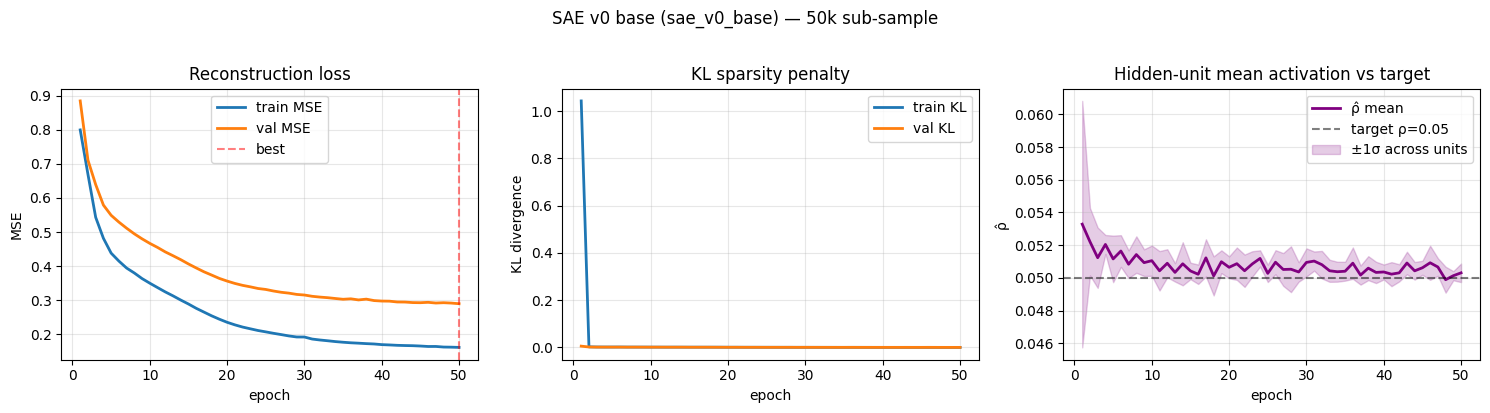

In [ ]:
h = summary_base['history']
ep = [r['epoch'] for r in h]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, [r['train_mse'] for r in h], label='train MSE', lw=2)
axes[0].plot(ep, [r['val_mse']   for r in h], label='val MSE',   lw=2)
axes[0].axvline(summary_base['best_epoch'], ls='--', c='red', alpha=0.5, label='best')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Reconstruction loss')

axes[1].plot(ep, [r['train_kl'] for r in h], label='train KL',  lw=2)
axes[1].plot(ep, [r['val_kl']   for r in h], label='val KL',    lw=2)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('KL divergence'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('KL sparsity penalty')

axes[2].plot(ep, [r['val_rho_hat_mean'] for r in h], label='ρ̂ mean', lw=2, c='purple')
axes[2].axhline(cfg_base.rho, ls='--', c='k', alpha=0.5, label=f'target ρ={cfg_base.rho}')
axes[2].fill_between(ep,
    [r['val_rho_hat_mean'] - r['val_rho_hat_std'] for r in h],
    [r['val_rho_hat_mean'] + r['val_rho_hat_std'] for r in h],
    alpha=0.2, color='purple', label='±1σ across units')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('ρ̂'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title('Hidden-unit mean activation vs target')

plt.suptitle(f'SAE v0 base ({cfg_base.run_name}) — 50k sub-sample', y=1.02)
plt.tight_layout()
out = FIG_DIR / '03_learning_curve.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## 3. Sanity check: recon error **benign** vs **attack**

Nếu SAE học đúng manifold benign, recon error trên flow attack phải **cao hơn rõ** so với benign. Đây là điều kiện cần (không đủ) để LOF trên latent space hoạt động tốt ở Tuần 5.

Đo trên một slice val.parquet để tiết kiệm RAM.

In [ ]:
# Load best checkpoint
ckpt = torch.load(CKPT_DIR / 'sae_v0_base_best.pt', map_location=DEVICE, weights_only=False)
model = SparseAutoencoder(
    input_dim=cfg_base.input_dim,
    hidden_dims=cfg_base.hidden_dims,
    latent_dim=cfg_base.latent_dim,
).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}, val_mse={ckpt["val_mse"]:.6f}')

Loaded best checkpoint from epoch 50, val_mse=0.290057


In [ ]:
# Load val.parquet và chia benign/attack
val_df = pd.read_parquet(DATA_DIR / 'val.parquet')

# EDA dùng convention y8 (8-class) — không phải 'Label'
# Dùng y8 cho sanity check vì BENIGN_LABEL được lấy từ label_encoder_8
LABEL_COL_CANDIDATES = ['y8', 'y_bin', 'y34', 'Label', 'label']
label_col = None
for c in LABEL_COL_CANDIDATES:
    if c in val_df.columns:
        label_col = c
        break
if label_col is None:
    raise ValueError(f'Không tìm thấy cột label. Columns: {list(val_df.columns)}')
print(f'Dùng label column: {label_col}')

# Stratified sample để tiết kiệm memory: 50k benign + 50k attack
N_SAMPLE = 50_000
benign_df = val_df[val_df[label_col] == BENIGN_LABEL]
attack_df = val_df[val_df[label_col] != BENIGN_LABEL]
if len(benign_df) > N_SAMPLE:
    benign_df = benign_df.sample(N_SAMPLE, random_state=0)
if len(attack_df) > N_SAMPLE:
    attack_df = attack_df.sample(N_SAMPLE, random_state=0)
print(f'Benign sample: {len(benign_df):,}  |  Attack sample: {len(attack_df):,}')

# Feature columns: loại TẤT CẢ các cột label (y_bin, y8, y34) khỏi feature set
# Không chỉ loại label_col đang dùng — nếu không sẽ leak label vào feature
ALL_LABEL_COLS = {'y_bin', 'y8', 'y34', 'Label', 'label'}
feat_cols = [c for c in val_df.columns if c not in ALL_LABEL_COLS]
print(f'n_features = {len(feat_cols)} (kỳ vọng 46)')
assert len(feat_cols) == 46, f'Số feature không đúng: {len(feat_cols)}'

X_benign = torch.from_numpy(benign_df[feat_cols].to_numpy(np.float32)).to(DEVICE)
X_attack = torch.from_numpy(attack_df[feat_cols].to_numpy(np.float32)).to(DEVICE)
print(f'X_benign shape: {tuple(X_benign.shape)}')
print(f'X_attack shape: {tuple(X_attack.shape)}')
del val_df, benign_df, attack_df  # free RAM

Dùng label column: y8
Benign sample: 50,000  |  Attack sample: 50,000
n_features = 46 (kỳ vọng 46)
X_benign shape: (50000, 46)
X_attack shape: (50000, 46)


/tmp/ipykernel_26140/1885606588.py:33: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  X_benign = torch.from_numpy(benign_df[feat_cols].to_numpy(np.float32)).to(DEVICE)


In [ ]:
@torch.no_grad()
def recon_errors(X, model, batch=4096):
    """Tính per-sample squared-error trung bình trên mọi feature."""
    errs = []
    for i in range(0, len(X), batch):
        x = X[i:i+batch]
        xh, _ = model(x)
        errs.append(((xh - x) ** 2).mean(dim=1).cpu().numpy())
    return np.concatenate(errs)

err_benign = recon_errors(X_benign, model)
err_attack = recon_errors(X_attack, model)

print(f'Benign recon MSE: mean={err_benign.mean():.4f}  median={np.median(err_benign):.4f}')
print(f'Attack recon MSE: mean={err_attack.mean():.4f}  median={np.median(err_attack):.4f}')
print(f'Ratio attack/benign (median): {np.median(err_attack) / np.median(err_benign):.2f}×')

Benign recon MSE: mean=0.1898  median=0.0268
Attack recon MSE: mean=849.4562  median=5.7260
Ratio attack/benign (median): 213.63×


Saved /home/kali/sae-lof-ids-pi5/figs/03_recon_hist.png
AUC (recon-MSE only, chưa qua LOF): 0.9942
FPR @ TPR=95%: 0.0071


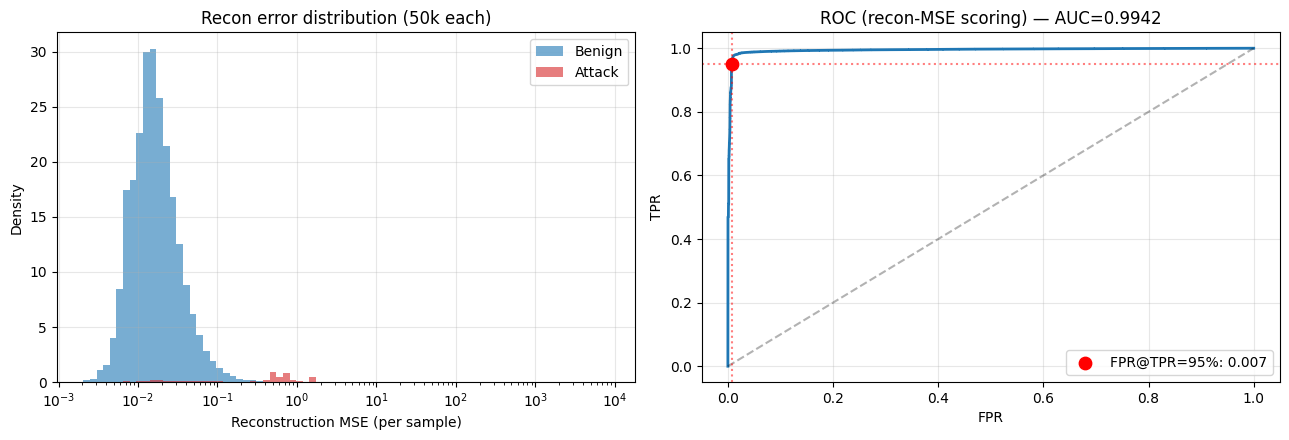

In [ ]:
# Histogram + AUC quick
from sklearn.metrics import roc_auc_score, roc_curve

y_true   = np.concatenate([np.zeros(len(err_benign)), np.ones(len(err_attack))])
y_score  = np.concatenate([err_benign, err_attack])
auc      = roc_auc_score(y_true, y_score)

fpr, tpr, thr = roc_curve(y_true, y_score)
# FPR tại TPR=95% theo metric của đề cương
idx_95 = np.argmin(np.abs(tpr - 0.95))
fpr_at_95 = fpr[idx_95]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Log-scale histogram vì tail của attack rất dài
bins = np.logspace(np.log10(max(1e-4, min(y_score))), np.log10(y_score.max()), 80)
axes[0].hist(err_benign, bins=bins, alpha=0.6, label='Benign', color='tab:blue', density=True)
axes[0].hist(err_attack, bins=bins, alpha=0.6, label='Attack', color='tab:red',  density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Reconstruction MSE (per sample)')
axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(f'Recon error distribution (50k each)')

axes[1].plot(fpr, tpr, lw=2)
axes[1].plot([0, 1], [0, 1], ls='--', c='k', alpha=0.3)
axes[1].axhline(0.95, ls=':', c='red', alpha=0.5)
axes[1].axvline(fpr_at_95, ls=':', c='red', alpha=0.5)
axes[1].scatter([fpr_at_95], [0.95], s=80, c='red', zorder=5,
    label=f'FPR@TPR=95%: {fpr_at_95:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
axes[1].set_title(f'ROC (recon-MSE scoring) — AUC={auc:.4f}')

plt.tight_layout()
out = FIG_DIR / '03_recon_hist.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
print(f'AUC (recon-MSE only, chưa qua LOF): {auc:.4f}')
print(f'FPR @ TPR=95%: {fpr_at_95:.4f}')
plt.show()

**Đọc kết quả sanity check:**

- Nếu **AUC recon-MSE ≥ 0.85** → SAE đã học manifold benign rõ, chuyển sang LOF ở Tuần 5 rất khả thi.
- Nếu **AUC 0.70–0.85** → chấp nhận được cho sub-sample 50k; Tuần 4 scale lên full 878k benign + 200 epoch sẽ cải thiện.
- Nếu **AUC < 0.70** → cảnh báo: kiểm tra lại scaler, feature quality, hoặc tăng latent_dim thử 12–16.

Ghi chú: đây chỉ là **score recon-MSE thô**, chưa phải điểm LOF trên latent space — điểm LOF thường cao hơn AUC recon-MSE khoảng 3–8%.

## 4. Mini grid search ρ × β (9 combo)

Chạy song song trong cell (không spawn subprocess) để giữ state rõ trong notebook.

In [ ]:
import itertools

RHOS  = [0.01, 0.05, 0.10]
BETAS = [1.0,  3.0,  10.0]
GRID  = list(itertools.product(RHOS, BETAS))
print(f'Total combos: {len(GRID)}')

ts       = time.strftime('%Y%m%d_%H%M%S')
grid_log = LOG_DIR / f'grid_{ts}';       grid_log.mkdir(exist_ok=True)
grid_ckp = CKPT_DIR / f'grid_{ts}';      grid_ckp.mkdir(exist_ok=True)

grid_results = []
t0 = time.time()
for i, (rho, beta) in enumerate(GRID, 1):
    run_name = f'rho={rho}_beta={beta}'
    print(f'\n--- [{i}/{len(GRID)}] {run_name} ---')
    cfg = TrainConfig(
        train_path=str(DATA_DIR / 'train_benign.parquet'),
        val_path  =str(DATA_DIR / 'val.parquet'),
        benign_label=BENIGN_LABEL,
        max_train_samples=50_000, max_val_samples=20_000,
        input_dim=46, hidden_dims=(32, 16), latent_dim=8,
        rho=rho, beta=beta,
        lr=1e-3, batch_size=256,
        max_epochs=50, patience=10,
        num_workers=2, device='auto', seed=0,
        run_name=run_name,
        ckpt_dir=str(grid_ckp), log_dir=str(grid_log),
        verbose_every=10,
    )
    s = train(cfg)
    last = s['history'][-1] if s['history'] else {}
    grid_results.append({
        'rho': rho, 'beta': beta,
        'best_val_mse': s['best_val_mse'],
        'best_epoch':   s['best_epoch'],
        'epochs_run':   s['total_epochs_run'],
        'final_rho_hat_mean': last.get('val_rho_hat_mean'),
        'final_rho_hat_std':  last.get('val_rho_hat_std'),
        'time_s': s['total_time_s'],
    })

print(f'\n=== Grid done in {time.time() - t0:.1f}s ===')

In [ ]:
grid_df = pd.DataFrame(grid_results).sort_values('best_val_mse').reset_index(drop=True)
grid_df['rho_hat_dev'] = (grid_df['final_rho_hat_mean'] - grid_df['rho']).abs()
grid_df.to_csv(grid_log / 'summary.csv', index=False)
print(grid_df.to_string(float_format='%.5f'))

### 4.1 Đánh giá AUC recon-MSE cho MỖI combo grid

val_MSE thấp ≠ detector tốt (có thể là under-regularized, không ép sparsity). Đo thêm AUC recon-MSE trên cùng slice benign/attack như §3.

In [ ]:
aucs = []
for rec in grid_results:
    rho, beta = rec['rho'], rec['beta']
    ck = grid_ckp / f'rho={rho}_beta={beta}_best.pt'
    ck_data = torch.load(ck, map_location=DEVICE, weights_only=False)
    m = SparseAutoencoder(input_dim=46, hidden_dims=(32,16), latent_dim=8).to(DEVICE)
    m.load_state_dict(ck_data['model_state_dict']); m.eval()
    eB = recon_errors(X_benign, m)
    eA = recon_errors(X_attack, m)
    yt = np.concatenate([np.zeros(len(eB)), np.ones(len(eA))])
    ys = np.concatenate([eB, eA])
    a  = roc_auc_score(yt, ys)
    aucs.append({'rho': rho, 'beta': beta, 'auc_recon': a})

auc_df = pd.DataFrame(aucs)
grid_full = grid_df.merge(auc_df, on=['rho','beta'])
grid_full = grid_full.sort_values('auc_recon', ascending=False).reset_index(drop=True)
grid_full.to_csv(grid_log / 'summary_with_auc.csv', index=False)
print(grid_full.to_string(float_format='%.5f'))

### 4.2 Heatmap AUC ρ × β

In [ ]:
piv_auc = grid_full.pivot(index='rho', columns='beta', values='auc_recon')
piv_mse = grid_full.pivot(index='rho', columns='beta', values='best_val_mse')
piv_dev = grid_full.pivot(index='rho', columns='beta', values='rho_hat_dev')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (piv, title, fmt, cmap) in zip(axes, [
    (piv_auc, 'AUC (recon-MSE)',     '.4f', 'viridis'),
    (piv_mse, 'Best val MSE',        '.4f', 'viridis_r'),
    (piv_dev, '|ρ̂ − ρ| deviation',  '.3f', 'magma_r'),
]):
    im = ax.imshow(piv.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel('β'); ax.set_ylabel('ρ')
    ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, f'{v:{fmt}}', ha='center', va='center',
                    c='white' if (cmap.endswith('_r') and v > piv.values.mean()) or
                                 (not cmap.endswith('_r') and v < piv.values.mean()) else 'black',
                    fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('SAE v0 mini grid ρ × β (50k benign, 50 epoch)', y=1.02)
plt.tight_layout()
out = FIG_DIR / '03_grid_heatmap.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## 5. Chọn best (ρ*, β*) — quyết định cho Tuần 4

**Tiêu chí lựa chọn đa mục tiêu:**
1. AUC recon-MSE cao nhất (ưu tiên #1 — đo trực tiếp khả năng phát hiện)
2. |ρ̂ − ρ| < 0.02 (KL đang thực sự bind — không phải trivial solution)
3. val MSE không quá tệ (tránh under-reconstruction)

Không chọn top-1 AUC nếu ρ̂ lệch xa target (nghĩa là sparsity không bind, hệ số β không có tác dụng).

In [ ]:
# Filter: |rho_hat - rho| < 0.02
ok = grid_full[grid_full['rho_hat_dev'] < 0.02].copy()
if len(ok) == 0:
    print('⚠ Không combo nào có |ρ̂ − ρ| < 0.02; nới về 0.05')
    ok = grid_full[grid_full['rho_hat_dev'] < 0.05].copy()

ok = ok.sort_values('auc_recon', ascending=False)
best = ok.iloc[0]
runner_up = ok.iloc[1] if len(ok) > 1 else None

print('CHỌN CHO TUẦN 4:')
print(f"  Primary : rho={best['rho']}, beta={best['beta']}  "
      f"(AUC={best['auc_recon']:.4f}, ρ̂={best['final_rho_hat_mean']:.3f})")
if runner_up is not None:
    print(f"  Backup  : rho={runner_up['rho']}, beta={runner_up['beta']}  "
          f"(AUC={runner_up['auc_recon']:.4f}, ρ̂={runner_up['final_rho_hat_mean']:.3f})")

In [ ]:
# Ghi configs/sae_v0_tuned.yaml cho Tuần 4
tuned_yaml = f"""# Auto-generated from notebook 03 — {time.strftime('%Y-%m-%d %H:%M')}
# Best config from Week 3 mini grid search ({len(GRID)} combos × 50k sub-sample × 50 epoch)
#
# Primary pick : rho={best['rho']}, beta={best['beta']}
#   AUC recon-MSE = {best['auc_recon']:.4f}
#   best val MSE  = {best['best_val_mse']:.5f}
#   rho_hat       = {best['final_rho_hat_mean']:.4f}  (dev = {best['rho_hat_dev']:.4f})
#
# Week 4 plan:
#   1) Scale: max_train_samples=null (full 878k benign), max_epochs=200
#   2) Repeat on seeds {{0, 1, 42, 123, 2026}}
#   3) Extended grid: rho ∈ [0.01, 0.05, 0.10, 0.20], beta ∈ [1, 3, 10]

run_name: sae_v0_tuned

data:
  train_path: /home/kali/sae-lof-ids-pi5/data/processed/train_benign.parquet
  val_path:   /home/kali/sae-lof-ids-pi5/data/processed/val.parquet
  benign_label: {BENIGN_LABEL}
  max_train_samples: null
  max_val_samples:   null

model:
  input_dim: 46
  hidden_dims: [32, 16]
  latent_dim: 8

loss:
  rho:  {best['rho']}
  beta: {best['beta']}

optim:
  lr: 0.001
  batch_size: 256
  max_epochs: 200
  patience: 10

infra:
  num_workers: 4
  device: auto
  seed: 0

logging:
  ckpt_dir: ./checkpoints
  log_dir:  ./logs
  verbose_every: 1
"""

conf_dir = PROJ_ROOT / 'configs'
conf_dir.mkdir(exist_ok=True)
out_yaml = conf_dir / 'sae_v0_tuned.yaml'
out_yaml.write_text(tuned_yaml)
print(f'Wrote {out_yaml}')

## 6. Deliverable checklist — Tuần 3 (M1-ready, tiến tới M2)

| # | Deliverable | Trạng thái |
|---|---|---|
| 1 | `src/sae_model.py` — SAE 46→32→16→8→16→32→46 (~4,374 params) | ✅ |
| 2 | `src/sae_losses.py` — MSE + β·KL(ρ‖ρ̂) | ✅ |
| 3 | `src/sae_dataset.py` — BenignFlowDataset + make_dataloaders | ✅ |
| 4 | `src/sae_train.py` — Adam + EarlyStopping + JSON history | ✅ |
| 5 | `src/sae_grid_search.py` — CLI grid runner | ✅ |
| 6 | `configs/sae_v0.yaml` — base config | ✅ |
| 7 | Model SAE v0 checkpoint (`checkpoints/sae_v0_base_best.pt`) | ✅ (cell 2) |
| 8 | Learning curves figure (`figs/03_learning_curve.png`) | ✅ (cell 2.1) |
| 9 | Sanity recon histogram + ROC (`figs/03_recon_hist.png`) | ✅ (§3) |
| 10 | Grid summary CSV + heatmap (`figs/03_grid_heatmap.png`) | ✅ (§4) |
| 11 | Tuned config `configs/sae_v0_tuned.yaml` cho Tuần 4 | ✅ (§5) |

## Kế hoạch Tuần 4 (13/05–19/05)

1. Chạy `sae_grid_search.py` với **extended grid 4×3 = 12 combo** trên **full 878,556 benign**, 200 epoch, **seed 0**.
2. Pick top-3 combo sau extended grid.
3. Repeat top-1 trên 5 seed {0, 1, 42, 123, 2026} → báo cáo mean ± std cho đề cương.
4. Lưu latent embeddings `z_benign_train.npy` + `z_val.npy` để Tuần 5 fit LOF.